# Интеллектуальный анализ данных – весна 2026

# Домашнее задание 7: Деревья. Случайный лес

Правила:

- Домашнее задание оценивается в 10 баллов.


- Можно использовать без доказательства любые результаты, встречавшиеся на лекциях или семинарах по курсу, если получение этих результатов не является вопросом задания.


- Можно использовать любые свободные источники с обязательным указанием ссылки на них.


- Плагиат не допускается. При обнаружении случаев списывания, 0 за работу выставляется всем участникам нарушения, даже если можно установить, кто у кого списал.

<!-- ![](meme.jpg) -->
<img src="meme.jpg" alt="Drawing" style="width: 700px;"/>

## Часть 1: Основы построения решающие дерева (1.5 балла)

В этой части все расчёты необходимо реализовывать в виде запрограммированных формул, например, на `numpy`. **Нельзя использовать готовые реализации**. Например, если в задании требуется рассчитать энтропию, то требуется в каком-то виде релизовать расчёт по формуле, но нельзя использовать готовую реализацию `some_module.entropy()`.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings("ignore")

**Задание 1.1 (0.5 балла)** Пусть известно, что в вершину решающего дерева попали 10 объектов, 8 из которых имеют метку класса $k_1$, а 2 имеют метку класса $k_2$. Рассчитайте энтропию такого распределения классов (с натуральным логарифмом). Ответ округлите до двух знаков после запятой.

In [2]:
def entropy(p):
    p = np.array(p)
    
    if p.ndim != 1:
        raise Exception("p must be 1 dimensional")
    if np.any(p < 0):
        raise Exception("probability can`t be negative")
    
    return -np.sum(p * np.log(p))

In [3]:
k1 = 8
k2 = 2
n = 10

np.round(entropy([k1 / n, k2 / n]), 2)

np.float64(0.5)

**Задание 1.2 (0.5 балла)** Пусть дополнительно известно, что вершина из предыдущего задания не является листовой и возможно такое разбиение, что в левое поддерево попадут все объекты класса $k_1$, а в правое - класса $k_2$. Посчитайте критерий информативности:

$$
Q(R_m, j, t) = H(R_m) - \frac{|R_\ell|}{|R_m|}H(R_\ell) - \frac{|R_r|}{|R_m|}H(R_r),
$$

где $R_m$ - множество объектов в разбиваемой вершине, $j$ - номер признака, по которому происходит разбиение, $t$ - порог разбиения, $R_\ell$ - множество объектов в левом поддереве, $R_r$ - множество объектов в правом поддереве.

Теперь в качестве $H(R)$ будем использовать индекс Джини:

$$
H(R) = \sum_{k=1}^J p_k(1-p_k),
$$
где $J$ – общее количество классов (в нашем случае, $J = 2$).

Ответ округлите до двух знаков после запятой.

In [4]:
def gini(p):
    p = np.array(p)
    
    if p.ndim != 1:
        raise Exception("p must be 1 dimensional")
    if np.any(p < 0):
        raise Exception("probability can`t be negative")
    
    return np.sum(p * (1 - p))

In [5]:
np.round(
    gini([k1 / n, k2 / n]) - k1 / n * gini([k1 / k1, 0]) - k2 / n * gini([k2 / k2, 0]),
    2
)

np.float64(0.32)

**Задание 1.3 (0.5 балла)** Пусть при построении дерева образовалась листовая вершина с 10 объектами, значения целевой переменной для которых следующие: [1, 10, 5, 18, 100, 30, 50, 61, 84, 47] (решается задача регрессии). Чему будут равны предсказания модели для этих объектов?

In [6]:
targets = [1, 10, 5, 18, 100, 30, 50, 61, 84, 47]
print(f"The prediction will be: {np.mean(targets)}")

The prediction will be: 40.6


## Часть 2: Решающие деревья (4.5 балла)

В этой части мы напишем и протестируем собственную реализацию решающего дерева.

In [7]:
from collections import Counter
from typing import Dict, List, Tuple, Union

**Задание 2.1 (1.5 балла)** Реализуйте функцию `find_best_split()`, которая должна находить оптимальное разбиение подмножества обучающей выборки в соответствии с информационным критерием из **Задания 1.2**. В качестве меры хаотичности $H(R)$ для задачи регрессии испольуйте дисперсию подвыборки, а для задачи классификации – критерий Джини (определён в том же задании).

Для категориальных признаков применяется наивный алгоритм разбиения: мы пытаемся найти одно значение, разбиение по которому сильнее всего увеличит критерий информативности. Иными словами, объекты с конкретным значением признака отправляем в левое поддерево, остальные - в правое. Обратите внимание, что это далеко не оптимальные способ учёта категориальных признаков. Например, можно было бы на каждое значение категориального признака создавать отдельное поддерево или использовать более сложные подходы. Подробнее об этом можно прочитать в конспектах [лекций](https://github.com/esokolov/ml-course-hse/blob/master/2019-fall/lecture-notes/lecture07-trees.pdf) по машинному обучению на ПМИ (раздел «Учёт категориальных признаков»).

В качестве подсказок реализации можете пользоваться кодом из бонусной части семинара по решающим деревьям.

**Бонус:** Разрешается делать цикл для перебора порогов, но возможна имплементация без него. За имплементацию без цикла – **бонус 1 балл**.

In [8]:
def find_best_split(
    feature_vector: Union[np.ndarray, pd.DataFrame], 
    target_vector: Union[np.ndarray, pd.Series],
    task: str = "classification",
    feature_type: str = "real"
) -> Tuple[np.ndarray, np.ndarray, float, float]:
    """
    Указания:
    * Пороги, приводящие к попаданию в одно из поддеревьев пустого множества объектов, не рассматриваются.
    * В качестве порогов, нужно брать среднее двух сосдених (при сортировке) значений признака
    * Поведение функции в случае константного признака может быть любым.
    * При одинаковых приростах Джини или дисперсии нужно выбирать минимальный сплит.
    * За наличие в функции циклов балл будет снижен. Векторизуйте! :)

    :param feature_vector: вещественнозначный вектор значений признака
    :param target_vector: вектор классов объектов,  len(feature_vector) == len(target_vector)
    :param task: либо `classification`, либо `regression`
    :param feature_type: либо `real`, либо `categorical`
    
    :return thresholds: отсортированный по возрастанию вектор со всеми возможными порогами, по которым объекты можно
     разделить на две различные подвыборки, или поддерева
    :return Q_values: вектор со значениями критерия информативности для каждого из порогов в thresholds len(ginis) == len(thresholds)
    :return threshold_best: оптимальный порог (число)
    :return Q_best: оптимальное значение критерия информативности (число)
    """
    
    feat = np.array(feature_vector)
    target = np.array(target_vector)
    target_size = len(target)
    
    if feat.ndim != 1 or target.ndim != 1:
        raise Exception("Features and targets must be a vector")
    if len(feat) != len(target):
        raise Exception("Features size must be equal to targets size")
    if task not in ["classification", "regression"]:
        raise Exception("Invalid 'task' value")
    if feature_type not in ["real", "categorical"]:
        raise Exception("Invalid 'feature_type' value")
    if np.isnan(target).sum():
        raise Exception("NaN values found in targets")
    if np.isinf(target).sum():
        raise Exception("Inf values found in targets")
    
    if feature_type == "real":
        feat_sorted = np.unique(feat)
        thresholds = (feat_sorted[1:] + feat_sorted[:-1]) / 2
    else:
        thresholds = np.unique(feat)
        
    left_masks = (
        feat.reshape(-1, 1) < thresholds.reshape(1, -1)
        if feature_type == "real"
        else feat.reshape(-1, 1) == thresholds.reshape(1, -1)
    )
    right_masks = ~left_masks
    
    left_sizes = left_masks.sum(axis=0)
    right_sizes = len(feat) - left_sizes
    
    valid = (left_sizes > 0) & (right_sizes > 0)
    Q_values = np.full(len(thresholds), -np.inf)
    
    if task == "classification":
        # делаем ohe
        y = pd.get_dummies(target).to_numpy(dtype=np.int32) 

        left_counts = left_masks.T @ y # получим для каждого threshold количество элементов попавших в левое поддерево для каждого из классов
        right_counts = y.sum(axis=0) - left_counts

        # считаем вероятности, каждую строку поделив на скаляр
        p_left = left_counts / left_sizes.reshape(-1, 1)
        p_right = right_counts / right_sizes.reshape(-1, 1)

        # считаем критерий Джини по этим вероятностям
        h_left = np.apply_along_axis(gini, 1, p_left)
        h_right = np.apply_along_axis(gini, 1, p_right)
    else:
        # берем значения таргета для элементов из левого поддерева
        left_values = np.where(
            left_masks,
            target.reshape(-1, 1),
            np.nan
        )
        
        # то же самое для правого
        right_values = np.where(
            right_masks,
            target.reshape(-1, 1),
            np.nan
        )
        
        # считаем дисперсию по строкам без учета nan
        h_left = np.nanvar(left_values, axis=0)
        h_right = np.nanvar(right_values, axis=0)
    
    def gini_from_target(y):
        _, counts = np.unique(y, return_counts=True)
        p = counts / len(y)
        return gini(p)
    
    H = gini_from_target if task == "classification" else np.var 
    Q_values[valid] = (
        H(target) 
        - left_sizes[valid] / target_size * h_left[valid]
        - right_sizes[valid] / target_size * h_right[valid] 
    )
    best_idx = np.argmax(Q_values)
        
    return (
        thresholds,
        Q_values,
        thresholds[best_idx],
        Q_values[best_idx]
    )

Эту функцию можно протестировать на датасете `California`.

In [9]:
from sklearn.datasets import fetch_california_housing

In [10]:
data = fetch_california_housing()
X = pd.DataFrame(data=data["data"], columns=data["feature_names"])
y = data["target"]
X.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25


In [11]:
y

array([4.526, 3.585, 3.521, ..., 0.923, 0.847, 0.894], shape=(20640,))

In [12]:
find_best_split(X["Population"], y, "regression", "real")

(array([4.00000e+00, 5.50000e+00, 7.00000e+00, ..., 1.62135e+04,
        2.24355e+04, 3.21240e+04], shape=(3887,)),
 array([9.92793118e-05, 1.08156734e-04, 3.25383995e-05, ...,
        7.37409822e-05, 6.24188017e-05, 2.54365299e-05], shape=(3887,)),
 np.float64(1160.5),
 np.float64(0.0028306480480058127))

Выведите график зависимости значения критерия ошибки от порогового значения при разбиении вершины по признаку `MedInc`.

In [13]:
th, q, best_th, best_q = find_best_split(X["MedInc"], y, "regression", "real")

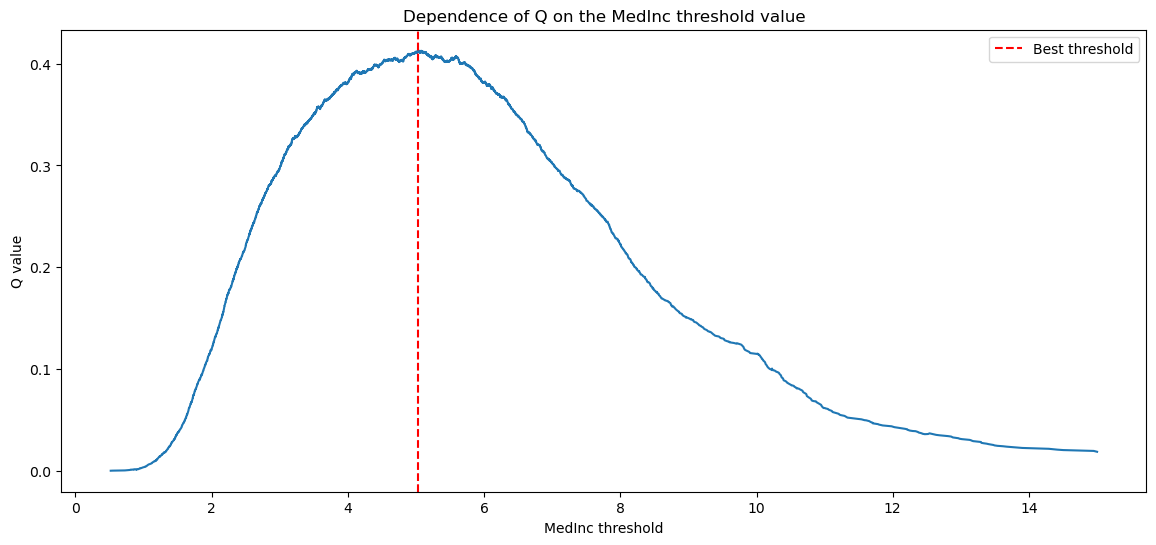

In [14]:
fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(th, q)
ax.set_title("Dependence of Q on the MedInc threshold value")
ax.set_xlabel("MedInc threshold")
ax.set_ylabel("Q value")
ax.axvline(best_th, color="red", linestyle="--", label="Best threshold")
ax.legend()

Найдите лучший, с вашей точки зрения, предикат первой вершины решающего дерева.

In [15]:
for col in X.columns:
    th, q, best_th, best_q = find_best_split(X[col], y, "regression", "real")
    print(f"Feature: {col} \t best Q: {best_q} with threshold {best_th}")

Feature: MedInc 	 best Q: 0.4127513862016673 with threshold 5.03515
Feature: HouseAge 	 best Q: 0.030900940598305587 with threshold 51.5
Feature: AveRooms 	 best Q: 0.15920795258922454 with threshold 6.374305146225346
Feature: AveBedrms 	 best Q: 0.015253415595924136 with threshold 1.1033776245480702
Feature: Population 	 best Q: 0.0028306480480058127 with threshold 1160.5
Feature: AveOccup 	 best Q: 0.07391870577794771 with threshold 3.1125433206272035
Feature: Latitude 	 best Q: 0.0903340876537015 with threshold 37.935
Feature: Longitude 	 best Q: 0.05021105203301035 with threshold -121.86500000000001


> Наибольшее значение `Q = 0.413` было получено для фичи `MedInc`. Поэтому лучший предикат будет `MedInc <= 5.03515`  

**Задание 2.2 (1 балл)** Разберитесь с написанным кодом решающего дерева, заполните пропуски в коде и реализуйте недостающий метод `_predict_node()`.

Построение дерева осуществляется согласно базовому жадному алгоритму, предложенному в лекции в разделе «Построение дерева».
- **Выбор лучшего разбиения** необходимо производить по критерию Джини.
- **Критерий останова:** все объекты в листе относятся к одному классу или ни по одному признаку нельзя разбить выборку.
- **Ответ в листе:** наиболее часто встречающийся класс в листе.

В задаче также предлагается получить два бонуса, по баллу на каждый!

- **Реализуйте способ обрабатывать пропуски в даннх и реализуйте его, пояснив свои действия.**
- **Реализуйте метод оценки важности признаков.**

In [16]:
from dataclasses import dataclass
from typing import Optional, Any, Callable

@dataclass
class Node:
    depth: int = 1
    is_leaf: bool = False
    
    value: Optional[Any] = None
    split_feature: Optional[int] = None
    split_predicate: Optional[Callable] = None
    
    left_child: Optional["Node"] = None
    right_child: Optional["Node"] = None

In [17]:
class DecisionTree:
    def __init__(
        self, 
        feature_types: Union[List[str], np.ndarray], 
        max_depth: int = None, 
        min_samples_split: int = None, 
        min_samples_leaf: int = None,
        task: str = "classification"
    ) -> None:
        
        if np.any(list(map(lambda x: x != "real" and x != "categorical", feature_types))):
            raise ValueError("There is unknown feature type")
        
        # типы признаков (категориальные или числовые)
        self._feature_types = feature_types
        
        # гиперпараметры дерева
        self._max_depth = max_depth
        self._min_samples_split = min_samples_split
        self._min_samples_leaf = min_samples_leaf
        self.task = task
        
        # Переменная, если вы решите делать бонус
        self._feature_importances = {}

    def _calc_node_value(
        self,
        y: np.ndarray
    ) -> Any:
        if self.task == "regression":
            return np.mean(y)
        values, counts = np.unique(y, return_counts=True)
        return values[np.argmax(counts)]

    def _fit_node(
        self, 
        node: Node,
        X: np.ndarray,
        y: np.ndarray,
    ) -> None:
        if (
            node.depth == self._max_depth
            or len(np.unique(y)) == 1
            or self._min_samples_split is not None and len(y) < self._min_samples_split
        ):
            node.is_leaf = True
            node.value = self._calc_node_value(y)
            return

        feature_best, th_best, q_best = None, None, None 
        for feature in range(X.shape[1]):
            feature_type = self._feature_types[feature]
            
            feature_vector = X[:, feature]
            _, _, th, q = find_best_split(feature_vector, y, self.task, feature_type)
            
            if q_best is None or q > q_best:
                q_best = q
                feature_best = feature
                th_best = th
        
        if feature_best is None:
            node.is_leaf = True
            node.value = self._calc_node_value(y)
            return
        
        if self._feature_types[feature_best] == "real":
            node.split_predicate = lambda x: x <= th_best
        else:
            node.split_predicate = lambda x: x == th_best
        
        mask = node.split_predicate(X[:, feature_best])
        
        if (
            self._min_samples_leaf is not None
            and (mask.sum() < self._min_samples_leaf or (~mask).sum() < self._min_samples_leaf)
        ):
            node.is_leaf = True
            node.split_predicate = None
            node.value = self._calc_node_value(y)
            return
        
        self._feature_importances[feature_best] = self._feature_importances.get(feature_best, 0) + q_best
        
        node.split_feature = feature_best
        node.left_child = Node(depth=node.depth + 1)
        node.right_child = Node(depth=node.depth + 1)
        
        self._fit_node(node.left_child, X[mask], y[mask])
        self._fit_node(node.right_child, X[~mask], y[~mask])

    def _predict_node(self, x: np.ndarray, node: Node) -> Any:
        if node.is_leaf:
            return node.value

        if node.split_predicate(x[node.split_feature]):
            return self._predict_node(x, node.left_child)
        return self._predict_node(x, node.right_child)

    def fit(self, X: np.ndarray, y: np.ndarray) -> DecisionTree:
        X = np.array(X)
        y = np.array(y)
        
        if np.isnan(X).sum() != 0:
            raise Exception("X contains NaN values")
        if np.isnan(y).sum() != 0:
            raise Exception("y contains NaN values")
        
        self._root = Node(1)
        self._fit_node(self._root, X, y)
        return self

    def predict(self, X: np.ndarray) -> np.ndarray:
        X = np.array(X)
        
        if np.isnan(X).sum() != 0:
            raise Exception("X contains NaN values")
        
        predicted = []
        for x in X:
            predicted.append(self._predict_node(x, self._root))
            
        return np.array(predicted)
    
    def get_feature_importances(self):
        return self._feature_importances

> Вынес узлы дерева в отдельный класс для удобства. В качестве оценки важности признака взято суммарное увеличение критерия информативности (есть соответствующий метод для ее получения). Пропуски в данных вызывают исключение. Заполнять данные модами и медианами не стал, т.к. посчитал, что это отдельная стадия пайплайна и не стоит ее вшивать в реализацию дерева.

**Задание 2.3 (1 балл)** Загрузите таблицу `students.csv` (это немного преобразованный датасет [User Knowledge](https://archive.ics.uci.edu/ml/datasets/User+Knowledge+Modeling)). В ней признаки объекта записаны в первых пяти столбцах, а в последнем записана целевая переменная (класс: 0 или 1). Постройте на одном изображении пять кривых "порог — значение критерия Джини" для всех пяти признаков. Отдельно визуализируйте диаграммы рассеяния "значение признака — класс" для всех пяти признаков.

In [18]:
data = pd.read_csv("students.csv", index_col=0)
X = data.iloc[:, :-1]
y = data.iloc[:, -1]

In [19]:
X.head()

,STG,SCG,STR,LPR,PEG
0,0.00,0.00,0.00,0.00,0.00
1,0.08,0.08,0.10,0.24,0.90
2,0.06,0.06,0.05,0.25,0.33
3,0.10,0.10,0.15,0.65,0.30
4,0.08,0.08,0.08,0.98,0.24


In [20]:
y.value_counts()

UNS
1    151
0    107
Name: count, dtype: int64

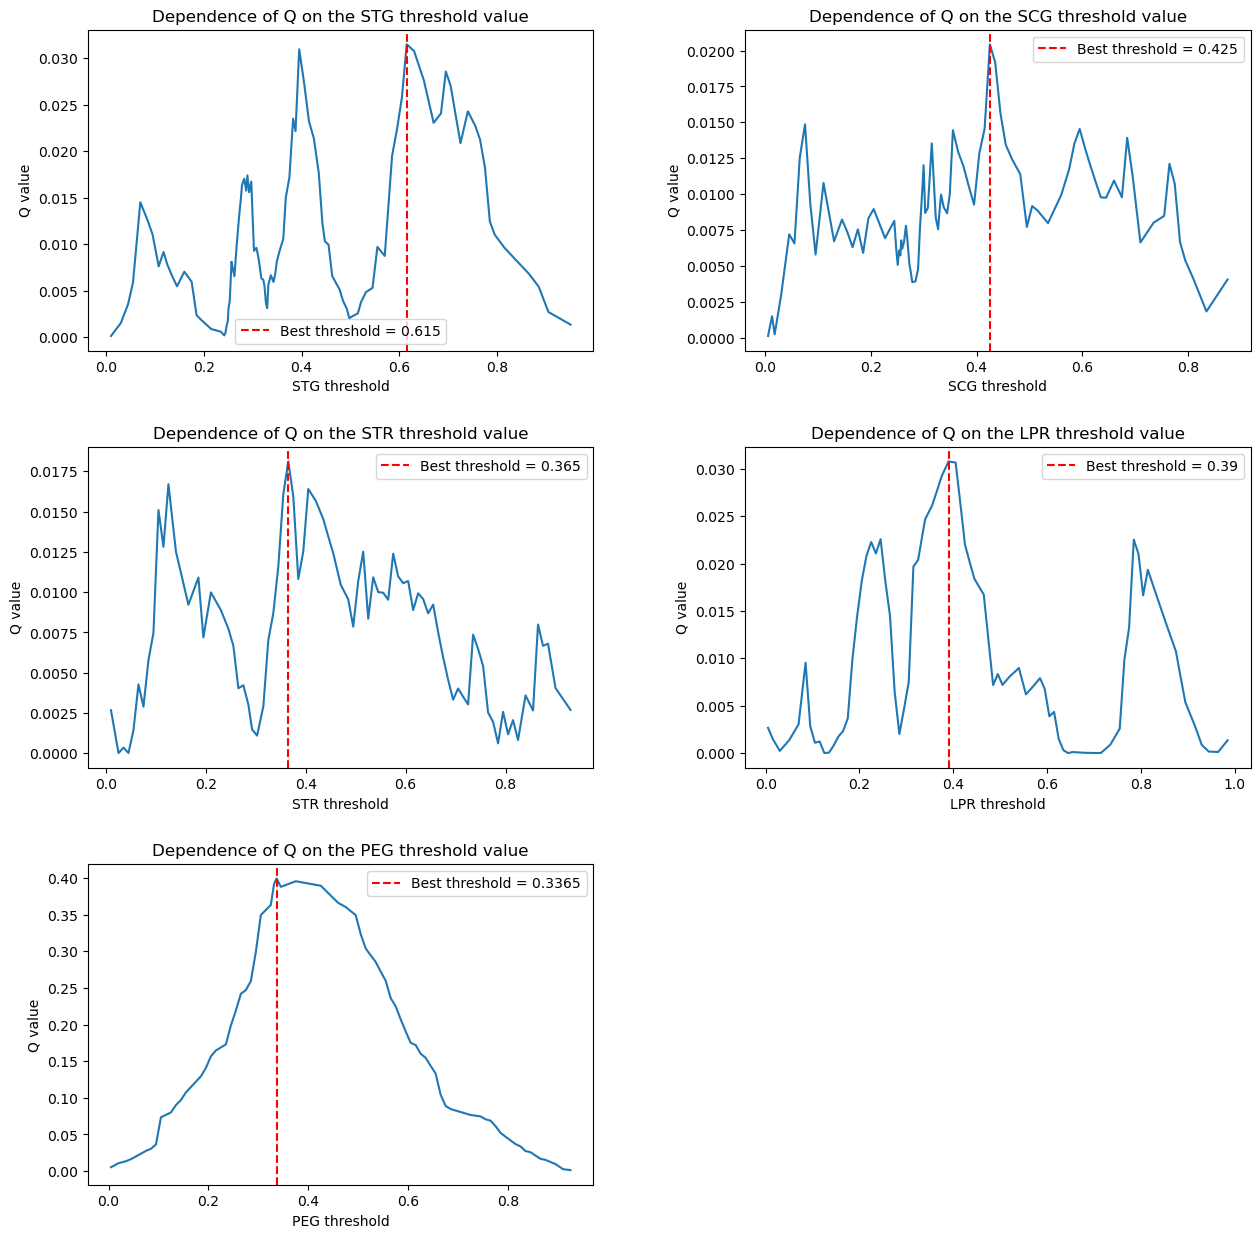

In [21]:
fig = plt.figure(figsize=(15, 15))

for i in range(X.columns.size):
    col = X.columns[i]
    th, q, best_th, best_q = find_best_split(X[col], y, "classification", "real")
    
    ax = fig.add_subplot(3, 2, i + 1)
    ax.plot(th, q)
    ax.set_title(f"Dependence of Q on the {col} threshold value")
    ax.set_xlabel(f"{col} threshold")
    ax.set_ylabel("Q value")
    ax.axvline(best_th, color="red", linestyle="--", label=f"Best threshold = {best_th}")
    ax.legend()

fig.subplots_adjust(hspace=0.3, wspace=0.3)

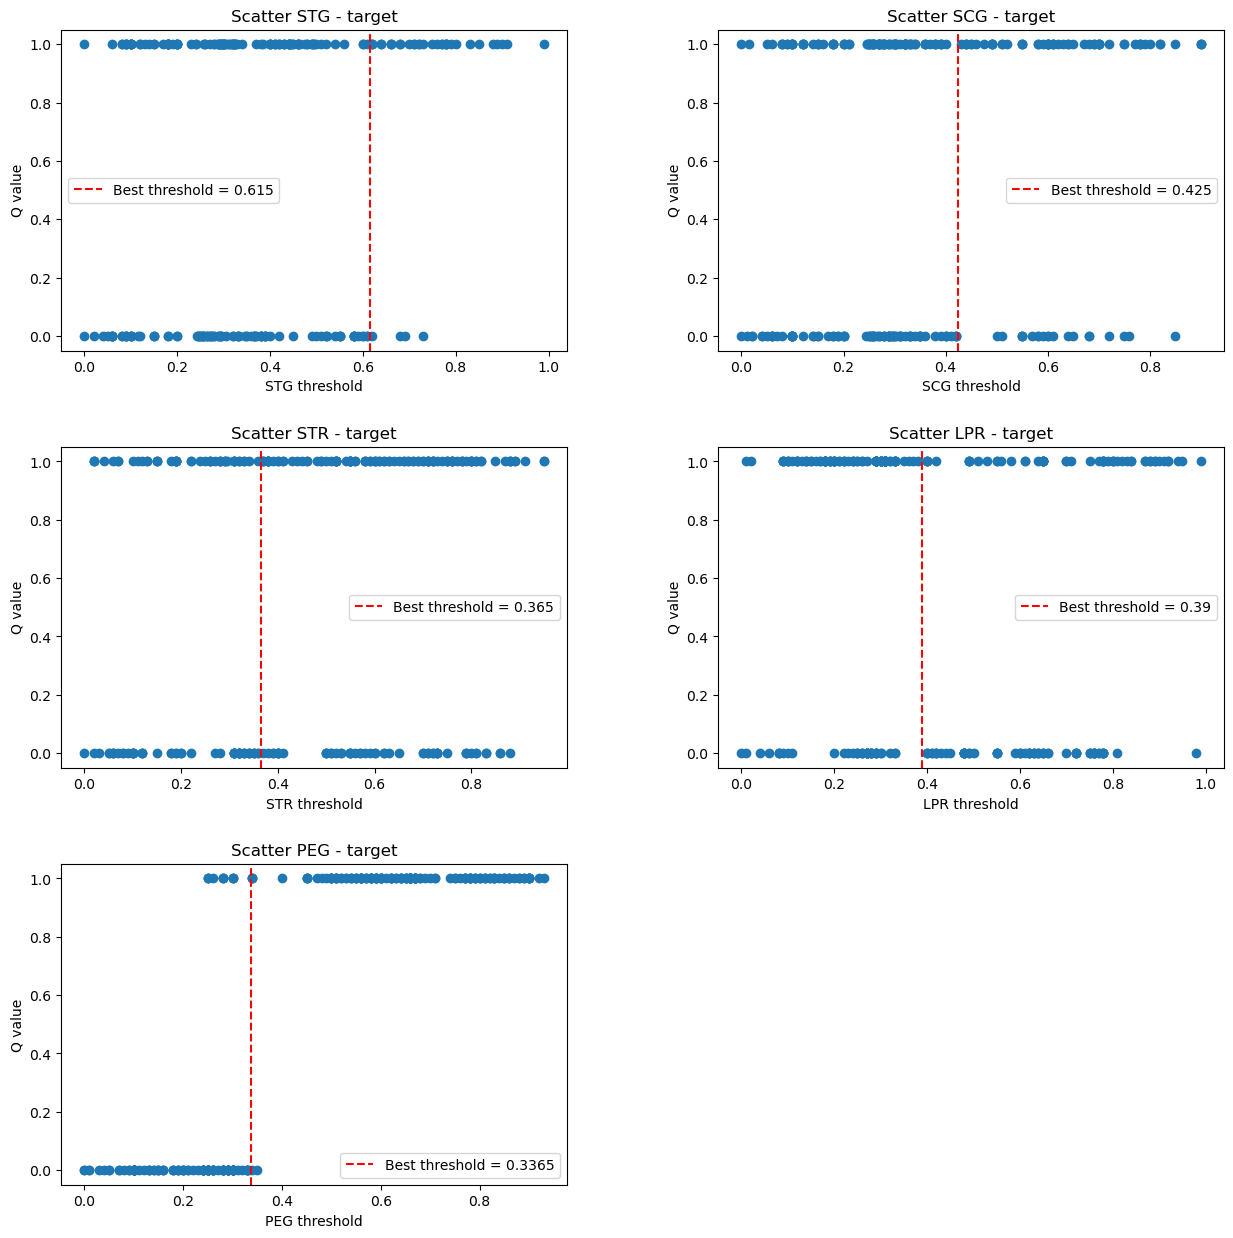

In [22]:
fig = plt.figure(figsize=(15, 15))

for i in range(X.columns.size):
    col = X.columns[i]
    _, _, best_th, _ = find_best_split(X[col], y, "classification", "real")
    
    ax = fig.add_subplot(3, 2, i + 1)
    ax.scatter(X[col], y)
    ax.set_title(f"Scatter {col} - target")
    ax.set_xlabel(f"{col} threshold")
    ax.set_ylabel("Q value")
    ax.axvline(best_th, color="red", linestyle="--", label=f"Best threshold = {best_th}")
    ax.legend()

fig.subplots_adjust(hspace=0.3, wspace=0.3)

Исходя из кривых значений критерия Джини, по какому признаку нужно производить деление выборки на два поддерева? Согласуется ли этот результат с визуальной оценкой диаграмм рассеяиния? Как бы охарактеризовали вид кривой для "хороших" признаков, по которым выборка делится почти идеально? Чем отличаются кривые для признаков, по которым деление практически невозможно?

> Лучше всех делит выборку на два поддерева признак `PEG`. Это подтверждается графиком значения Q, т.к. среди всех признаков у `PEG` оно принимает наибольшее значение. Диаграмма рассеяния также подтверждает это, т.к. `PEG` заметно лучше разделил значения.  
> Визуально графики для "хороших" признаков имеют ярко выраженный максимум и достаточно высокие значения в его окрестности, а "плохие" выглядят сильно зашумленными и не имеют выраженного максимума. 

**Задание 2.4 (1 балл)** Протестируйте свое решающее дерево на датасете [mushrooms](https://archive.ics.uci.edu/ml/datasets/Mushroom). 

1. Скачайте таблицу `agaricus-lepiota.data` (находится в директории с ноутбуком), 
2. Считайте таблицу при помощи `pandas`,
3. Примените к каждому столбцу `LabelEncoder` (из `sklearn`), чтобы преобразовать строковые имена категорий в натуральные числа. 

Первый столбец — это целевая переменная (e — edible, p — poisonous) Мы будем измерять качество с помощью accuracy, так что нам не очень важно, что будет классом 1, а что — классом 0. Обучите решающее дерево на половине случайно выбранных объектов (признаки в датасете категориальные) и сделайте предсказания для оставшейся половины. Вычислите accuracy.

In [23]:
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

data = pd.read_csv("agaricus-lepiota.data", header=None)

for col in data.columns:
    data[col] = LabelEncoder().fit_transform(data[col])

X, y = data.iloc[:, 1:], data.iloc[:, 0]
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=144, test_size=0.5, shuffle=True)

In [24]:
model = DecisionTree(
    feature_types=np.array(["categorical"] * X.shape[1]),
    task="classification",
).fit(X_train, y_train)

y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)
print(f"Accuracy on train: {accuracy_score(y_train, y_train_pred)}")
print(f"Accuracy on test: {accuracy_score(y_test, y_test_pred)}")

Accuracy on train: 1.0
Accuracy on test: 1.0


> Accuracy на train равно 1, т.к. глубина дерева не ограничена и оно подстроилось под обучающую выборку. На test accuracy также 1, скорее всего из-за особенностей датасета. 

## Часть 3: Бэггинг и случайный лес (4 балла)

В данной части мы будем работать [с задачей предсказания диабета у пациента](https://www.kaggle.com/uciml/pima-indians-diabetes-database/data). Посмотрим на работу бэггинга над решающими деревьями и случайного леса, сравним их работу.

In [25]:
from sklearn.ensemble import BaggingClassifier, RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, roc_auc_score
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier

In [26]:
data = pd.read_csv('diabetes.csv')
print(f"Dataset shape: {data.shape}")
data.head()

Dataset shape: (768, 9)


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


Посмотрим на распределение целевой переменной

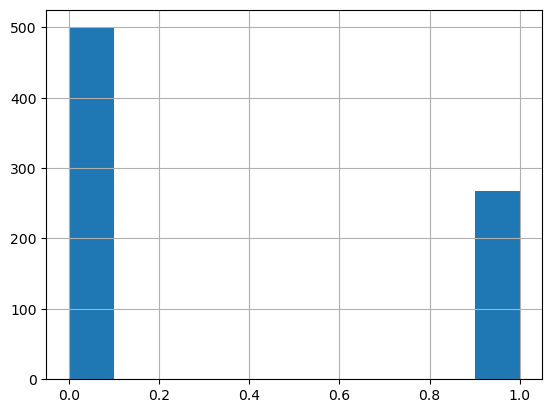

In [27]:
data['Outcome'].hist()
plt.show()

**Задание 3.1 (0.5 балла)** Разделите данные на признаки и целевую переменную. Разбейте датасет на обучающую и тестовую части в отношении 7:3. Затем разделите обучающую выборку на обучающую-обучающую и обучающую-валидационную в соотношении 7:3 (то есть в итоге должно получиться три выборки: обучающая-обучающая (0.49 от исходного датасета), обучающая-валидационная (0.21 от исходного датасета) и тестовая (0.3 от исходного датасета).

In [28]:
X, y = data.iloc[:, :-1], data.iloc[:, -1]
X_train_full, X_test, y_train_full, y_test = train_test_split(X, y, test_size=0.3, stratify=y, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_train_full, y_train_full, test_size=0.3, stratify=y_train_full, random_state=42)

**Задание 3.2 (1 балл)** На обучающей-валидационной выборке подберите оптимальные значения гиперпараметров `max_depth` и `min_samples_leaf` для `DecisionTreeClassifier`. Для этого:
1. Создайте списки с возможными значениями для перебора.
2. Для каждой пары значений обучите дерево на обучающей-обучающей выборке и определите качество на обучающей-валидационной выборке. В качестве критерия будем использовать `f1-меру`.
3. Выберите ту пару значений, которая даёт наилучшее качество на обучающей-валидационной выборке. 


Обучите решающее дерево с подобранными гиперпараметрами на **полной обучающей** выборке. Оцените качество классификации на тестовой выборке по метрикам `accuracy`, `precision` и `recall`, `auc_roc`.

In [29]:
from itertools import product
from sklearn.metrics import f1_score

max_depth_values = np.arange(1, 100)
min_samples_leaf_values = np.arange(1, 100)

best_md, best_msl, best_f1 = None, None, None
for max_depth, min_samples_leaf in product(max_depth_values, min_samples_leaf_values):
    model = DecisionTreeClassifier(
        max_depth=max_depth,
        min_samples_leaf=min_samples_leaf
    ).fit(X_train, y_train)
    
    f1 = f1_score(y_val, model.predict(X_val))
    
    if best_f1 is None or f1 > best_f1:
        best_md = max_depth
        best_msl = min_samples_leaf
        best_f1 = f1
        
print(f"Best max_depth: {best_md}")
print(f"Best min_samples_leaf: {best_msl}")

Best max_depth: 4
Best min_samples_leaf: 36


In [30]:
from sklearn.metrics import precision_score, recall_score, roc_auc_score

dtc = DecisionTreeClassifier(
    max_depth=best_md,
    min_samples_leaf=best_msl,
).fit(X_train_full, y_train_full)

print(f"Accuracy score: {accuracy_score(y_test, dtc.predict(X_test))}")
print(f"Precision score: {precision_score(y_test, dtc.predict(X_test))}")
print(f"Recall score: {recall_score(y_test, dtc.predict(X_test))}")
print(f"AUC-ROC score: {roc_auc_score(y_test, dtc.predict_proba(X_test)[:, 1])}")

Accuracy score: 0.7619047619047619
Precision score: 0.703125
Recall score: 0.5555555555555556
AUC-ROC score: 0.7892181069958848


**Задание 3.3 (0.5 балла)** Обучите [`BaggingClassifier`](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.BaggingClassifier.html) на 50 деревьях на **полной обучающей** выборке. Оцените качество классификации на тестовой выборке по тем же метрикам.

In [31]:
bc = BaggingClassifier(
    n_estimators=50,
    random_state=42
).fit(X_train_full, y_train_full)

print(f"Accuracy score: {accuracy_score(y_test, bc.predict(X_test))}")
print(f"Precision score: {precision_score(y_test, bc.predict(X_test))}")
print(f"Recall score: {recall_score(y_test, bc.predict(X_test))}")
print(f"AUC-ROC score: {roc_auc_score(y_test, bc.predict_proba(X_test)[:, 1])}")

Accuracy score: 0.7532467532467533
Precision score: 0.6875
Recall score: 0.5432098765432098
AUC-ROC score: 0.8269135802469136


> В данном случае обычное решающее дерево показало результаты немного лучше бэггинга по всем метрикам кроме AUC-ROC. Вероятно, выбранное дерево уже не обладает высокой дисперсией из-за ограничений max_depth и min_samples_leaf, поэтому ансамблирование не даёт существенного выигрыша.

**Задание 3.4 (1 балл)** Выполните кросс-валидацию на полной обучающей выборке и подберите оптимальные значения гиперпараметров `max_depth` и `min_samples_split` для `Random Forest` с 50 деревьями. Для этого:

1. Создайте списки с возможными значениями для перебора.
2. Для каждой пары значений проведите кросс-валидацию на полной обучающей выборке. Количество разбиений выберите на ваш вкус. В качестве критерия будем использовать `f1-меру`. Усредните значение критерия по всем прогонам кросс-валидации. 
3. Выберите ту пару значений, которая даёт наилучшее среднее качество. 

Обучите случайный лес с подобранными гиперпараметрами на **полной обучающей** выборке. Оцените качество классификации по тем же метрикам. Какая из трёх построенных моделей показала себя лучше?

In [32]:
from sklearn.model_selection import cross_val_score

max_depth_values = np.arange(1, 15)
min_samples_split_values = np.arange(2, 100)

best_md, best_mss, best_f1 = None, None, None
for max_depth, min_samples_split in product(max_depth_values, min_samples_split_values):
    rf = RandomForestClassifier(
        max_depth=max_depth,
        min_samples_split=min_samples_split,
        random_state=42,
        n_estimators=50,
    )
    
    mean_f1 = cross_val_score(rf, X_train_full, y_train_full, cv=5, scoring="f1").mean()
    
    if best_f1 is None or mean_f1 > best_f1:
        best_md = max_depth
        best_mss = min_samples_split
        best_f1 = mean_f1
        
print(f"Best max_depth: {best_md}")
print(f"Best min_samples_split: {best_mss}")

Best max_depth: 10
Best min_samples_split: 18


In [33]:
rf = RandomForestClassifier(
    max_depth=best_md,
    min_samples_split=best_mss,
    random_state=42,
    n_estimators=50,
).fit(X_train_full, y_train_full)

print(f"Accuracy score: {accuracy_score(y_test, rf.predict(X_test))}")
print(f"Precision score: {precision_score(y_test, rf.predict(X_test))}")
print(f"Recall score: {recall_score(y_test, rf.predict(X_test))}")
print(f"AUC-ROC score: {roc_auc_score(y_test, rf.predict_proba(X_test)[:, 1])}")

Accuracy score: 0.7445887445887446
Precision score: 0.671875
Recall score: 0.5308641975308642
AUC-ROC score: 0.8227160493827161


**Задание 3.5 (0.5 балла)** Постройте график зависимости AUC ROC на тестовой выборке от числа деревьев (`n_estimators`) для случайного леса, обучаемого на **полной обучающей** выборке. Какие выводы можно сделать?

In [37]:
n_values = np.arange(1, 500)
scores = []

for n in n_values:
    model = RandomForestClassifier(n_estimators=n, random_state=42).fit(X_train_full, y_train_full)
    scores += [roc_auc_score(y_test, model.predict_proba(X_test)[:, 1])]

Text(0, 0.5, 'ROC-AUC score')

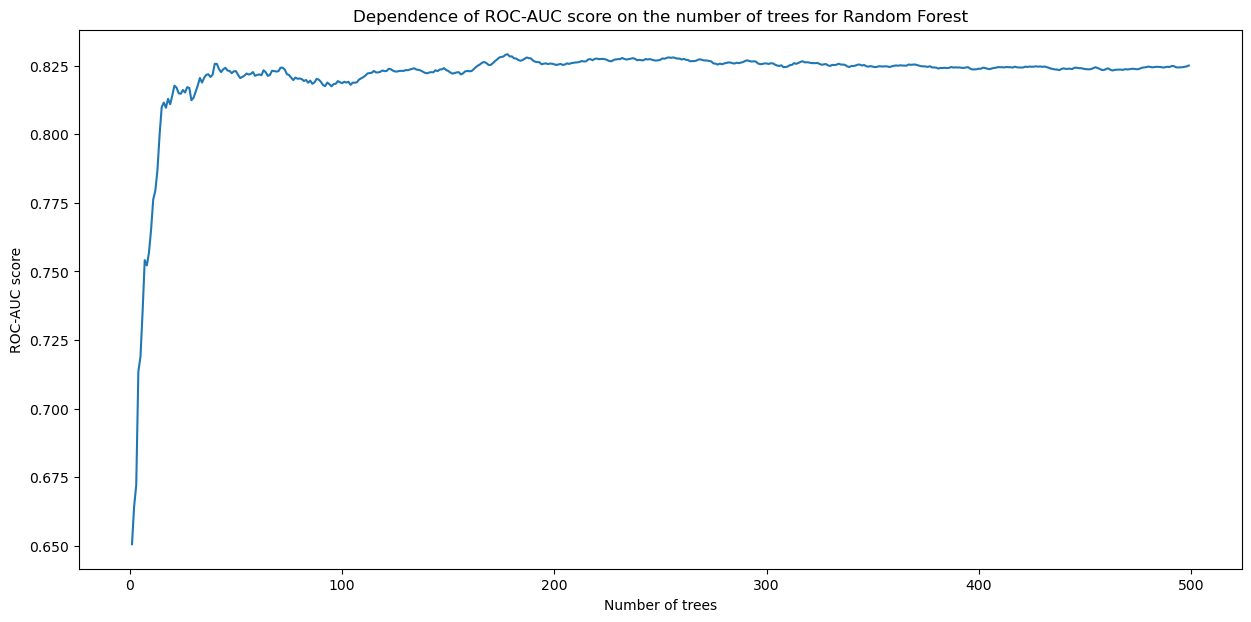

In [38]:
fig, ax = plt.subplots(figsize=(15, 7))

ax.plot(n_values, scores)
ax.set_title("Dependence of ROC-AUC score on the number of trees for Random Forest")
ax.set_xlabel("Number of trees")
ax.set_ylabel("ROC-AUC score")

> С увеличением числа деревьев ROC-AUC быстро возрастает, но после примерно 50 деревьев начинает изменяться незначительно. Также можно заметить, что при большом количестве деревьев кривая становится более стабильной, поскольку ансамбль усредняет ошибки отдельных деревьев и уменьшает дисперсию модели. Максимальное качество достигается примерно при 170 деревьях, после чего прирост практически отсутствует.

**Задание 3.6 (0.5 балла)** Для лучшей модели случайного леса из **Задания 3.4** посчитайте важность признаков и постройте bar plot. Какой признак оказался самым важным для определения диабета?

Text(0, 0.5, 'Importance')

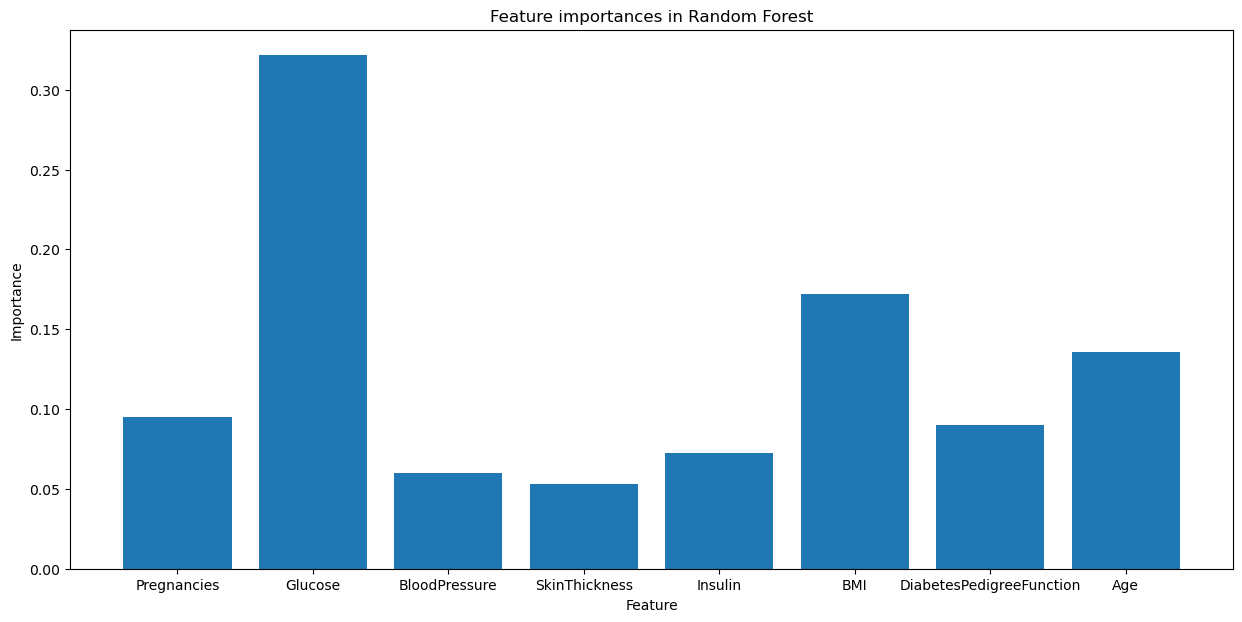

In [36]:
importances = rf.feature_importances_

fig, ax = plt.subplots(figsize=(15, 7))
ax.bar(X.columns, importances)
ax.set_title("Feature importances in Random Forest")
ax.set_xlabel("Feature")
ax.set_ylabel("Importance")

> Самым важным признаком для определения диабета оказался уровень глюкозы. Это логично, т.к. повышенный уровень глюкозы напрямую связан с диабетом. 